<a href="https://colab.research.google.com/github/lanaozeki08-jpg/SERS_CP2/blob/main/SERS_CP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [7]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [8]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [9]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [10]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)

## tarefa 1: CLASSIFICAÇÃO

In [11]:
import pandas as pd
aneel = pd.read_csv('/content/aneel_classificacao_orange.csv')

In [12]:
# examinar valores ausentes
aneel.isnull().sum()

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
# Algoritmos do sklearn para classificação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Separação os dados de treino e teste
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test

# Métricas para classificação
from sklearn.metrics import accuracy_score  # acurácia
from sklearn.metrics import confusion_matrix # identificação de onde o modelo errou
from sklearn.metrics import classification_report # resumo de métricas

In [14]:
aneel.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [15]:
aneel['fonte'].value_counts()

,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


In [16]:
# Features
X = aneel.drop(['fonte'], axis=1)
X.head()

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000


In [17]:
# Variável alvo (target)
y = aneel['fonte']
y.head()

,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_knn = KNeighborsClassifier()
modelo_logreg = LogisticRegression(max_iter=1000)
modelo_rf = RandomForestClassifier(random_state=42)

In [20]:
modelo_knn = modelo_knn.fit(X_train, y_train)
modelo_logreg = modelo_logreg.fit(X_train, y_train)
modelo_rf = modelo_rf.fit(X_train, y_train)

In [21]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_knn = modelo_knn.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

print(f"ACURÁCIA GERAL KNN: {accuracy_score(y_test, y_pred_knn):.2%}")
print(classification_report(y_test, y_pred_knn))

print(f"\nACURÁCIA GERAL RANDOM FOREST: {accuracy_score(y_test, y_pred_rf):.2%}")
print(classification_report(y_test, y_pred_rf))


ACURÁCIA GERAL KNN: 85.18%
              precision    recall  f1-score   support

      Eólica       0.81      0.79      0.80       247
  Hidráulica       0.88      0.87      0.87       298
       Solar       0.86      0.89      0.88       231

    accuracy                           0.85       776
   macro avg       0.85      0.85      0.85       776
weighted avg       0.85      0.85      0.85       776


ACURÁCIA GERAL RANDOM FOREST: 97.55%
              precision    recall  f1-score   support

      Eólica       0.98      0.96      0.97       247
  Hidráulica       0.97      0.99      0.98       298
       Solar       0.97      0.97      0.97       231

    accuracy                           0.98       776
   macro avg       0.98      0.97      0.97       776
weighted avg       0.98      0.98      0.98       776



In [22]:
modelo_LR = LogisticRegression()

In [23]:
modelo_LR.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [24]:
# Gerando as previsões
y_predict = modelo_LR.predict(X_test)
y_predict

array(['Solar', 'Solar', 'Hidráulica', 'Hidráulica', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Eólica',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Solar', 'Hidráulica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar', 'Solar', 'Solar',
       'Eólica', 'Eólica', 'Eólica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Eólica',
       'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar', 'Eólica',
       'Eólica', 'Eólica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Eólica', 'Eólica', 'Solar', 'Hidráulica', 'Solar', 'Solar',
       'Solar', 'Hidráulica', 'Hidráulica', 'Solar', 'Solar', 'Eólica',
       'Hidráulica', '

In [25]:
# Acurácia
acuracia = 100 * accuracy_score(y_test, y_predict)
print(f'A acurácia do modelo baseado em Regressão Logística é: {acuracia:.2f} %')

A acurácia do modelo baseado em Regressão Logística é: 73.32 %


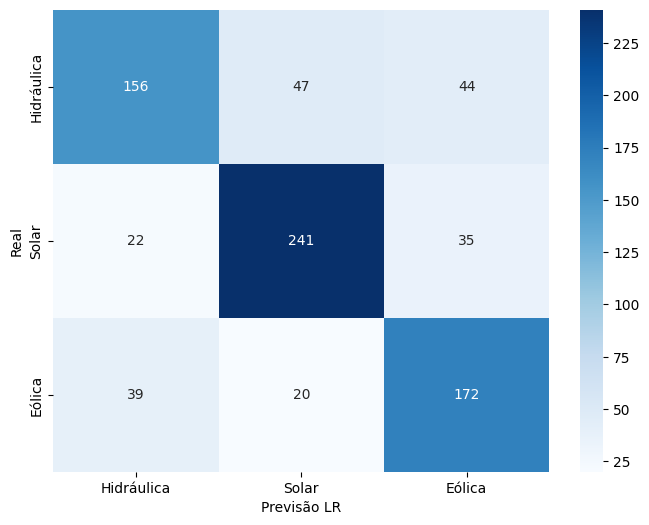

In [26]:
from sklearn.metrics import confusion_matrix

# 1. Calcule as previsões do seu modelo (se já não tiver feito)
y_pred = modelo_LR.predict(X_test)

# 2. Calcule a matriz e guarde na variável 'dados_da_matriz'
dados_da_matriz = confusion_matrix(y_test, y_pred)

# 3. Agora passe 'dados_da_matriz' para o heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(dados_da_matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hidráulica', 'Solar', 'Eólica'], yticklabels=['Hidráulica', 'Solar', 'Eólica'])
plt.xlabel('Previsão LR')
plt.ylabel('Real')
plt.show()


In [27]:
# Classification Report
report = classification_report(y_test, y_predict)
print(report)

              precision    recall  f1-score   support

      Eólica       0.72      0.63      0.67       247
  Hidráulica       0.78      0.81      0.80       298
       Solar       0.69      0.74      0.71       231

    accuracy                           0.73       776
   macro avg       0.73      0.73      0.73       776
weighted avg       0.73      0.73      0.73       776



In [28]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_knn = modelo_knn.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

print(f"ACURÁCIA GERAL KNN: {accuracy_score(y_test, y_pred_knn):.2%}")
print(classification_report(y_test, y_pred_knn))

print(f"\nACURÁCIA GERAL RANDOM FOREST: {accuracy_score(y_test, y_pred_rf):.2%}")
print(classification_report(y_test, y_pred_rf))

ACURÁCIA GERAL KNN: 85.18%
              precision    recall  f1-score   support

      Eólica       0.81      0.79      0.80       247
  Hidráulica       0.88      0.87      0.87       298
       Solar       0.86      0.89      0.88       231

    accuracy                           0.85       776
   macro avg       0.85      0.85      0.85       776
weighted avg       0.85      0.85      0.85       776


ACURÁCIA GERAL RANDOM FOREST: 97.55%
              precision    recall  f1-score   support

      Eólica       0.98      0.96      0.97       247
  Hidráulica       0.97      0.99      0.98       298
       Solar       0.97      0.97      0.97       231

    accuracy                           0.98       776
   macro avg       0.98      0.97      0.97       776
weighted avg       0.98      0.98      0.98       776



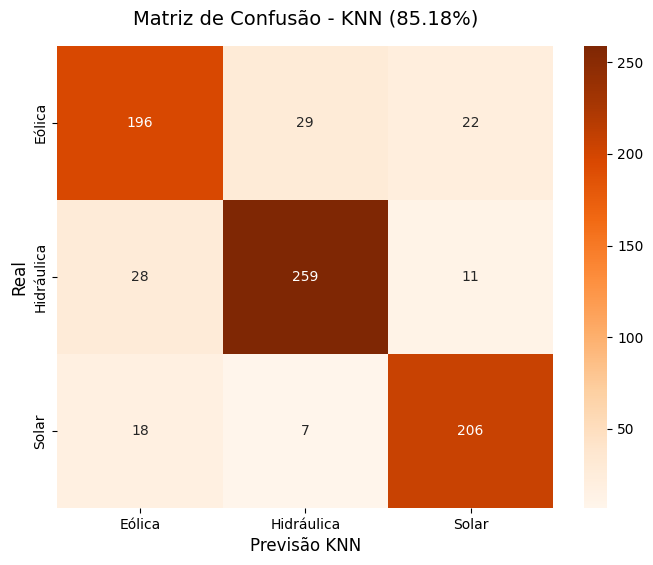

In [29]:
#matriz de confusão do modelo KNN

y_pred_knn = modelo_knn.predict(X_test)

dados_da_matriz_knn = confusion_matrix(y_test, y_pred_knn)

nomes_das_classes = ['Eólica', 'Hidráulica', 'Solar']

plt.figure(figsize=(8, 6))
sns.heatmap(dados_da_matriz_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=nomes_das_classes, yticklabels=nomes_das_classes)

plt.title('Matriz de Confusão - KNN (85.18%)', fontsize=14, pad=15)
plt.xlabel('Previsão KNN', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.show()


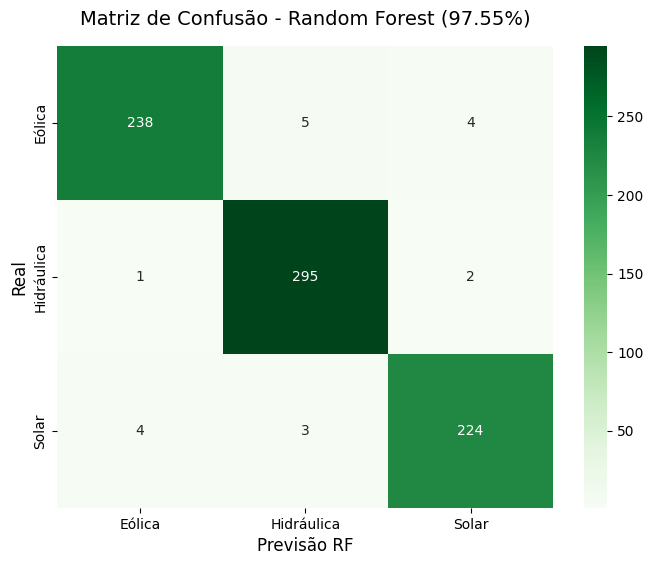

In [30]:
# matriz de confusão do modelo random forest

y_pred_rf = modelo_rf.predict(X_test)

dados_da_matriz = confusion_matrix(y_test, y_pred_rf)

# --- CÓDIGO NOVO AQUI ---
# Use exatamente isso para garantir o alinhamento correto dos rótulos:
classes_corretas = modelo_rf.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(dados_da_matriz, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes_corretas, yticklabels=classes_corretas)
# ------------------------

plt.title('Matriz de Confusão - Random Forest (97.55%)', fontsize=14, pad=15)
plt.xlabel('Previsão RF', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.show()


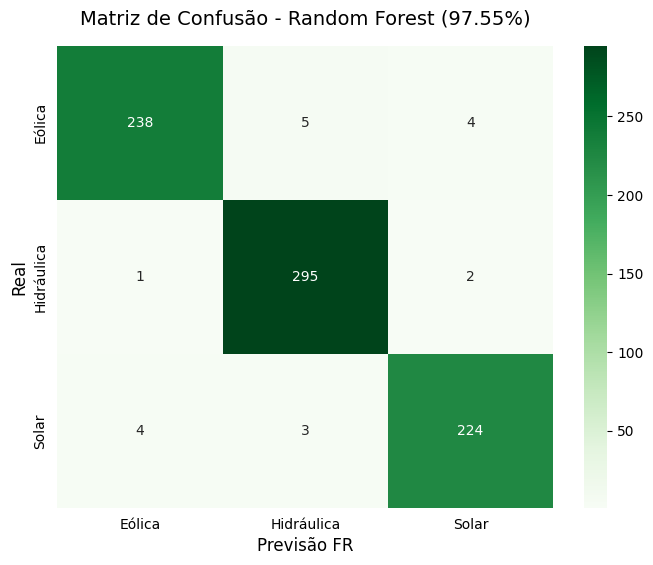

In [ ]:
# matriz de confusão do modelo random forest

y_pred_rf = modelo_rf.predict(X_test)

dados_da_matriz = confusion_matrix(y_test, y_pred_rf)

nomes_das_classes = ['Eólica', 'Hidráulica', 'Solar']

plt.figure(figsize=(8, 6))
sns.heatmap(dados_da_matriz, annot=True, fmt='d', cmap='Greens',
            xticklabels=nomes_das_classes, yticklabels=nomes_das_classes)

plt.title('Matriz de Confusão - Random Forest (97.55%)', fontsize=14, pad=15)
plt.xlabel('Previsão FR', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.show()


In [34]:
# tabela comparativa dos 3 algoritmos
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

y_pred_logreg = modelo_logreg.predict(X_test)

resultados = {}

modelos = {
    'K-Neighbors (KNN)': y_pred_knn,
    'Regressão Logística': y_pred_logreg,
    'Random Forest': y_pred_rf
}

for nome, preds in modelos.items():
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')

    resultados[nome] = {
        'Acurácia Geral': f"{acc:.2%}",
        'Precisão (Macro)': f"{prec:.2%}",
        'Recall (Macro)': f"{rec:.2%}",
        'F1-Score (Macro)': f"{f1:.2%}"
    }

df_comparativo = pd.DataFrame(resultados).T
df_comparativo


,Acurácia Geral,Precisão (Macro),Recall (Macro),F1-Score (Macro)
K-Neighbors (KNN),85.18%,84.99%,85.15%,85.06%
Regressão Logística,82.99%,83.26%,82.47%,82.52%
Random Forest,97.55%,97.56%,97.44%,97.50%


O modelo Random Forestt é o que tem maior acurácia, precisão, recall e f1, sendo o melhor modelo a ser escolhido. As classes que le mais confunde é a Eólica, com 96% de recall.

 a potência e localização não bastam para uma aplicação real porque em alguns mesmos pontos geográficos, usinas solares e eólicas podem ser construídas (independem do local), além disso, todas as usinas de fontes diferentes podem ter a mesma capacidade de potência na Aneel. apenas com essas variáveis também não é possível ter um resultado exato, já que ele depende também de fatores como: proximidade de corpos d' água, irradiação solar, velocidade dos ventos.

## tarefa 2: REGRESSÃO

In [35]:
meteo = pd.read_csv('/content/meteo_regressao_orange.csv')

In [36]:
meteo.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
# Instanciando o modelo_LR com base na classe LinearRegression
modelo_LR = LinearRegression()

In [39]:
# Features
X = meteo.drop(['radiacao_w_m2', 'data_hora'], axis=1)
X.head()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11


In [40]:
# Variável alvo (target)
y = meteo['radiacao_w_m2']
y.head()

,radiacao_w_m2
0,116.0
1,269.0
2,529.0
3,797.0
4,880.0


In [41]:
meteo = meteo.sort_values('data_hora').reset_index(drop=True)

In [43]:
# Divisão Temporal (80% treino, 20% teste) - Sem embaralhar (shuffle=False)
tamanho_treino = int(len(meteo) * 0.8)

X_train = X.iloc[:tamanho_treino]
X_test = X.iloc[tamanho_treino:]
y_train = y.iloc[:tamanho_treino]
y_test = y.iloc[tamanho_treino:]

print("\nEntradas do modelo (X):", list(X.columns))



Entradas do modelo (X): ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']


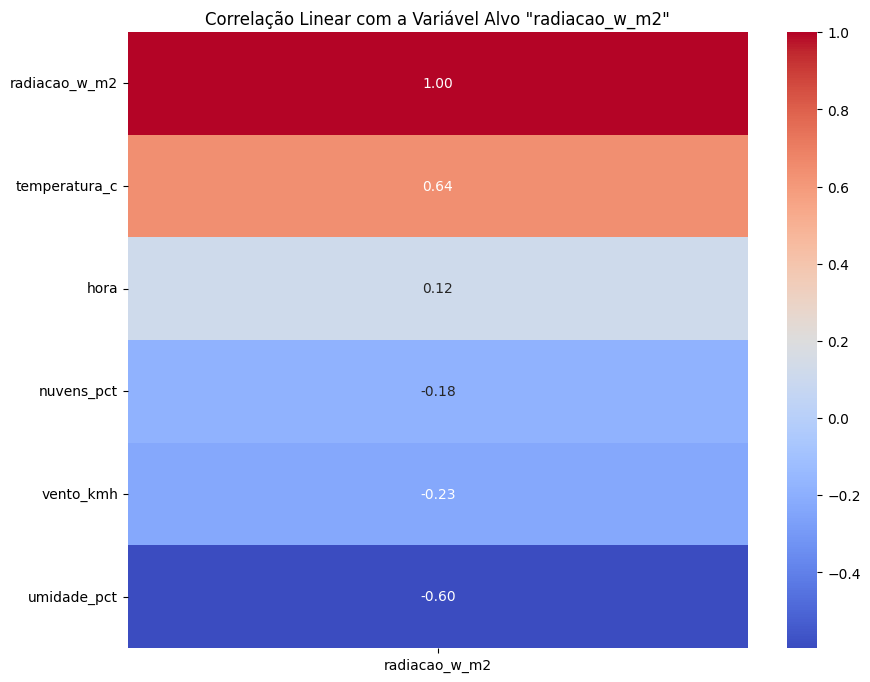

Correlações com a variável 'radiacao_w_m2':
radiacao_w_m2    1.000000
temperatura_c    0.642733
hora             0.120143
nuvens_pct      -0.180196
vento_kmh       -0.229388
umidade_pct     -0.596183
Name: radiacao_w_m2, dtype: float64


In [44]:
# Calculate the correlation matrix
correlacao_matrix = meteo.corr(numeric_only=True)

# Get correlations with 'stab' variable
correlacao_meteo = correlacao_matrix['radiacao_w_m2'].sort_values(ascending=False)

# Plotting the heatmap of correlations with 'stab'
plt.figure(figsize=(10, 8))
sns.heatmap(correlacao_meteo.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação Linear com a Variável Alvo "radiacao_w_m2"')
plt.show()

print("Correlações com a variável 'radiacao_w_m2':")
print(correlacao_meteo)

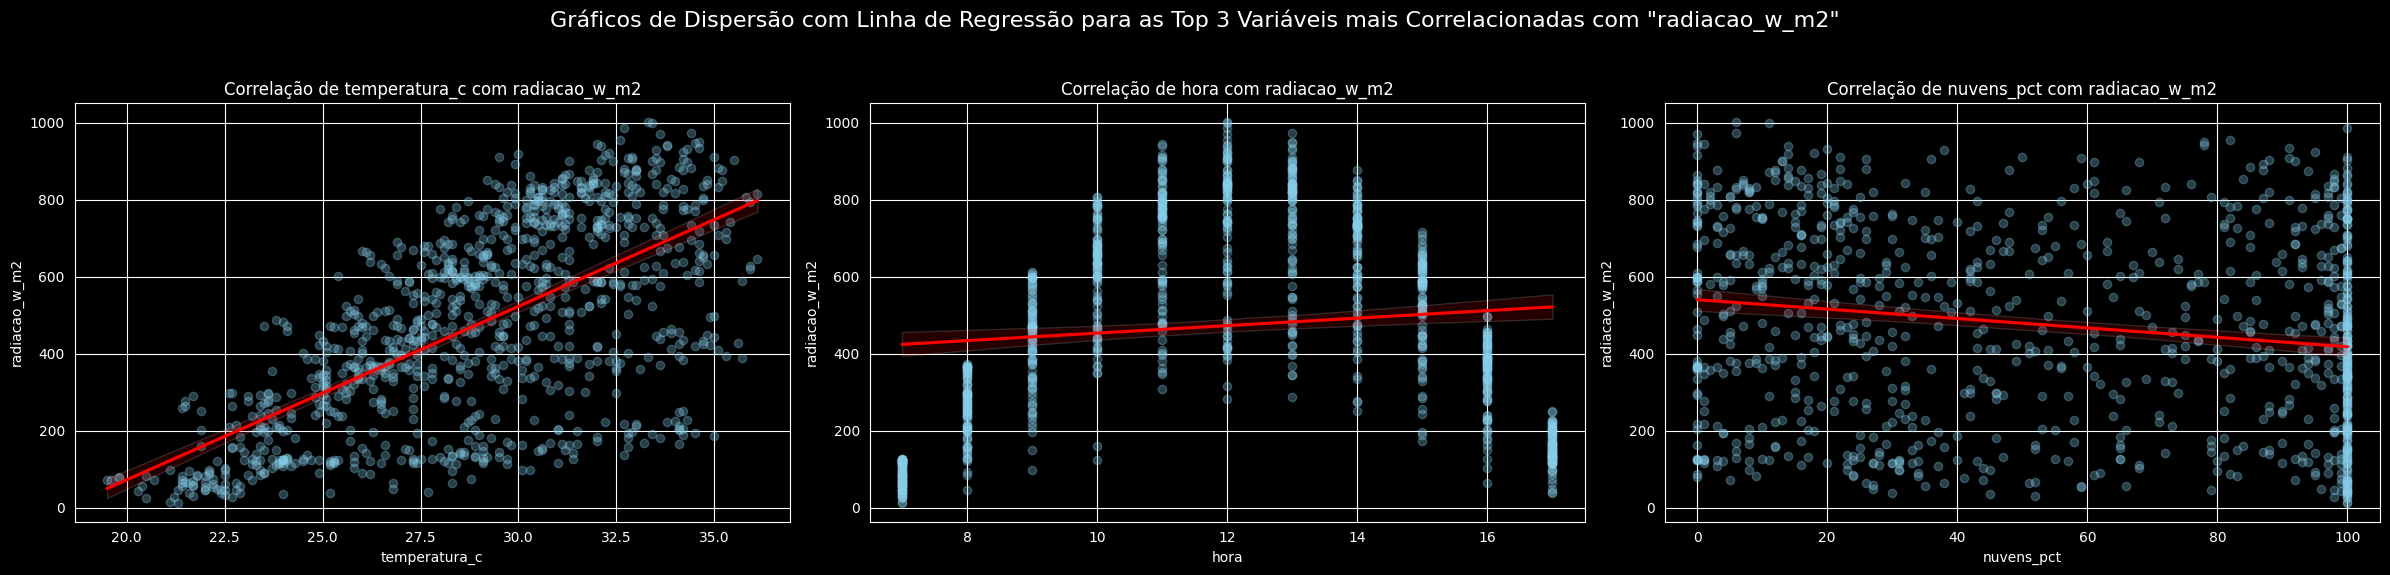

In [46]:
# Get the top 3 correlated features with 'radiacao_w_m2' (excluding 'stab' itself)
top_3_features = correlacao_meteo[1:4].index.tolist()

# Set the style for the plots and background color
sns.set_style("darkgrid", {"axes.facecolor": "black", "figure.facecolor": "black"})
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Gráficos de Dispersão com Linha de Regressão para as Top 3 Variáveis mais Correlacionadas com "radiacao_w_m2"', color='white', fontsize=16)

for i, feature in enumerate(top_3_features):
    sns.regplot(x=feature, y='radiacao_w_m2', data=meteo, ax=axes[i], scatter_kws={'alpha':0.3, 'color':'skyblue'}, line_kws={'color':'red'})
    axes[i].set_title(f'Correlação de {feature} com radiacao_w_m2', color='white')
    axes[i].set_xlabel(feature, color='white')
    axes[i].set_ylabel('radiacao_w_m2', color='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

# Reset default style if needed for subsequent plots
sns.set_style("darkgrid")
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Instanciar os algoritmos exigidos
modelo_lr = LinearRegression()
modelo_rf = RandomForestRegressor(random_state=42)
modelo_knn = KNeighborsRegressor()

# Treinar todos com o conjunto de treino
modelo_lr.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)
modelo_knn.fit(X_train, y_train)

# Fazer as previsões no conjunto de teste
y_pred_lr = modelo_lr.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)
y_pred_knn = modelo_knn.predict(X_test)

# Montar a tabela comparativa de métricas
modelos_reg = {
    'Regressão Linear': y_pred_lr,
    'Random Forest Regressor': y_pred_rf,
    'K-Neighbors Regressor (KNN)': y_pred_knn
}

resultados_reg = {}
for nome, preds in modelos_reg.items():
    resultados_reg[nome] = {
        'MAE (W/m²)': f"{mean_absolute_error(y_test, preds):.2f}",
        'MSE ((W/m²)²)': f"{mean_squared_error(y_test, preds):.2f}",
        'R² (Score)': f"{r2_score(y_test, preds):.4f}"
    }

df_comparativo_reg = pd.DataFrame(resultados_reg).T
df_comparativo_reg


,MAE (W/m²),MSE ((W/m²)²),R² (Score)
Regressão Linear,145.20,30034.20,0.3598
Random Forest Regressor,66.80,7307.42,0.8442
K-Neighbors Regressor (KNN),100.88,18942.57,0.5963


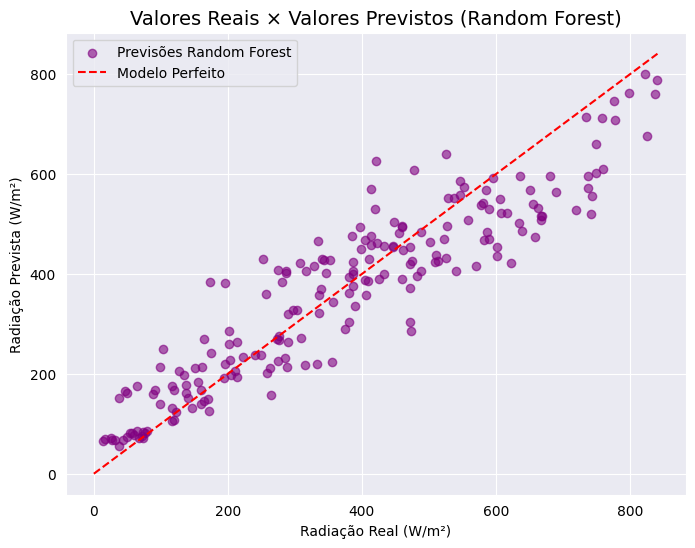

In [48]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='purple', label='Previsões Random Forest')

# Linha ideal
limite_max = max(max(y_test), max(y_pred_rf))
plt.plot([0, limite_max], [0, limite_max], color='red', linestyle='--', label='Modelo Perfeito')

plt.title('Valores Reais × Valores Previstos (Random Forest)', fontsize=14)
plt.xlabel('Radiação Real (W/m²)')
plt.ylabel('Radiação Prevista (W/m²)')
plt.legend()
plt.show()


--- TABELA COMPARATIVA DE REGRESSÃO ---


,MAE (W/m²),MSE ((W/m²)²),R² (Score)
Regressão Linear Múltipla,145.20,30034.20,0.3598
Random Forest Regressor,66.80,7307.42,0.8442
K-Neighbors Regressor (KNN),100.88,18942.57,0.5963


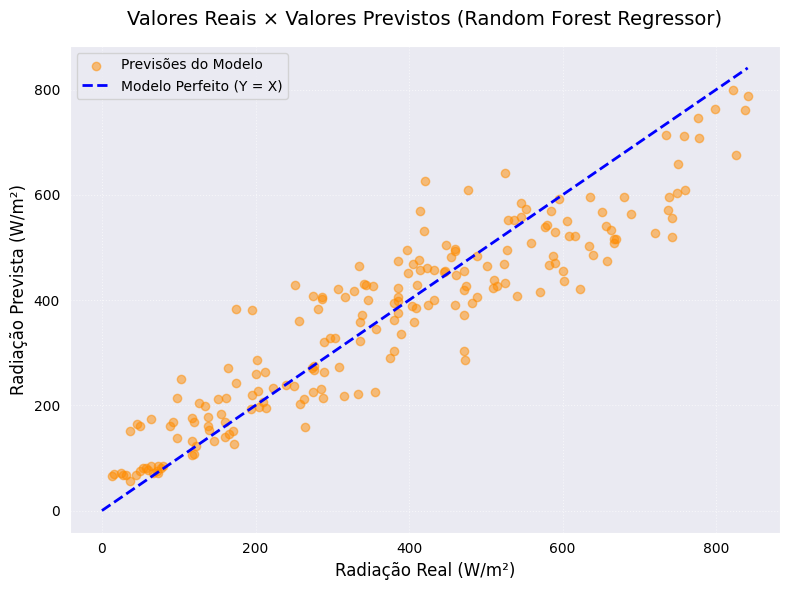

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. Criar o dicionário com as predições de teste que calculamos anteriormente
modelos_reg = {
    'Regressão Linear Múltipla': y_pred_lr,
    'Random Forest Regressor': y_pred_rf,
    'K-Neighbors Regressor (KNN)': y_pred_knn
}

# 2. Calcular e estruturar as métricas na tabela
resultados_reg = {}
for nome, preds in modelos_reg.items():
    resultados_reg[nome] = {
        'MAE (W/m²)': f"{mean_absolute_error(y_test, preds):.2f}",
        'MSE ((W/m²)²)': f"{mean_squared_error(y_test, preds):.2f}",
        'R² (Score)': f"{r2_score(y_test, preds):.4f}"
    }

df_comparativo_reg = pd.DataFrame(resultados_reg).T
print("--- TABELA COMPARATIVA DE REGRESSÃO ---")
display(df_comparativo_reg)

# 3. Gerar o gráfico de Valores Reais × Valores Previstos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='darkorange', label='Previsões do Modelo')

# Linha de Identidade (O cenário perfeito onde o previsto é exatamente igual ao real)
limite_max = max(max(y_test), max(y_pred_rf))
plt.plot([0, limite_max], [0, limite_max], color='blue', linestyle='--', linewidth=2, label='Modelo Perfeito (Y = X)')

plt.title('Valores Reais × Valores Previstos (Random Forest Regressor)', fontsize=14, pad=15)
plt.xlabel('Radiação Real (W/m²)', fontsize=12)
plt.ylabel('Radiação Prevista (W/m²)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


O erro médio absoluto MAE é menor no modelo Random Forest. o modelo de Regressão Linear tem um erro quadrático médio MSE muito alto pq não consegue mapear bem o comportamento do sol, gerando erros em certos horários. Já o coeficiente de determinação R2 tem o maior valor no Random Forest, modelos em árvores são melhores em padrões não lineares do que lineares, ao contrário do modelo de Regressão Linear.

a variável hora é mais importante já que a radiação solar é como uma curva, baixa as 7h, pico as 12h e baixa as 17h, a hora não deixa que o modelo confunda radiação solar com calor, já que as 17h pode estar muito quente mas com o sol já se pondo.

a quantidade de radiação não é a mesma da energia gerada pois dependendo da eficiência da placa, parte da radiação pode ser perdida (após passar do limite), se o ambiente estiver muito quente/abafado, as placas não funcionam em sua eficiência máxima, assim como se as mesas estiverem sujas, com mau manuntenção da parte elétrica.  